In [94]:
# ImpulseGuard — Step 1
# Environment Test

import sys
import tensorflow as tf
import librosa
import numpy as np
import scipy
import soundfile as sf
import matplotlib.pyplot as plt

print("✅ Python:", sys.version.split()[0])
print("✅ TensorFlow:", tf.__version__)
print("✅ Librosa:", librosa.__version__)
print("✅ NumPy:", np.__version__)
print("✅ SciPy:", scipy.__version__)
print("✅ SoundFile:", sf.__version__)

print("\n🎉 ImpulseGuard ML environment is working!")

✅ Python: 3.13.7
✅ TensorFlow: 2.21.0
✅ Librosa: 1.0.0
✅ NumPy: 2.5.2
✅ SciPy: 1.18.1
✅ SoundFile: 0.14.0

🎉 ImpulseGuard ML environment is working!


In [95]:

audio, sr = librosa.load(
    "../data/tests/speech1.wav",
    sr=None,
    mono=False
)

print("Sample rate:", sr)
print("Shape:", audio.shape)

Sample rate: 44100
Shape: (2, 2136306)


In [96]:
print(audio[:20])
print(type(audio))
print(audio.dtype)

[[-0.0118103   0.00082397 -0.00524902 ...  0.03591919  0.04284668
   0.03427124]
 [-0.01239014 -0.00222778 -0.00741577 ...  0.09320068  0.10546875
   0.0838623 ]]
<class 'numpy.ndarray'>
float32


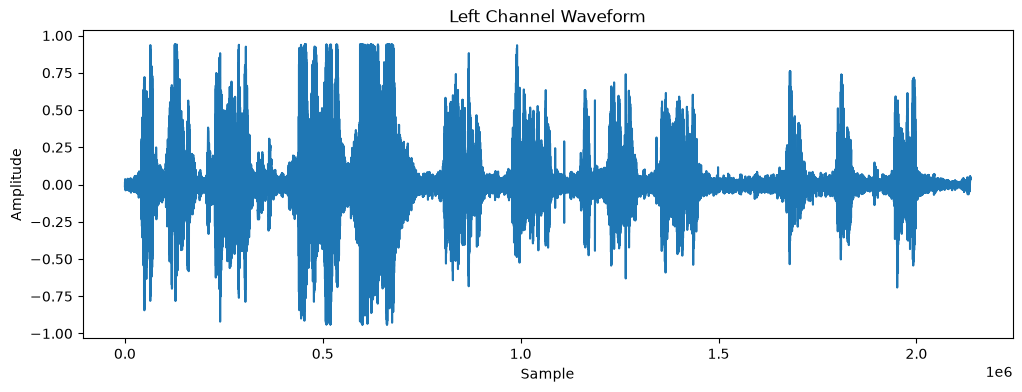

In [97]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))

plt.plot(audio[0])

plt.title("Left Channel Waveform")
plt.xlabel("Sample")
plt.ylabel("Amplitude")

plt.show()

In [98]:
print("Number of channels:", audio.shape[0])
print("Samples per channel:", audio.shape[1])
print("Sample rate:", sr)

duration = audio.shape[1] / sr
print("Duration:", duration, "seconds")

Number of channels: 2
Samples per channel: 2136306
Sample rate: 44100
Duration: 48.44231292517007 seconds


In [99]:
mono_audio = librosa.to_mono(audio)

print("Original shape:", audio.shape)
print("Mono shape:", mono_audio.shape)

Original shape: (2, 2136306)
Mono shape: (2136306,)


In [100]:
print("First 10 mono samples:")
print(mono_audio[:10])
print("Mono dtype:", mono_audio.dtype)

First 10 mono samples:
[-0.01210022 -0.0007019  -0.0063324  -0.00636292 -0.00643921 -0.00308228
 -0.00082397 -0.00080872 -0.00265503 -0.0025177 ]
Mono dtype: float32


In [101]:
audio_16k = librosa.resample(
    mono_audio,
    orig_sr=sr,
    target_sr=16000
)

print("Original sample rate:", sr)
print("New sample rate:", 16000)
print("Original samples:", len(mono_audio))
print("New samples:", len(audio_16k))

Original sample rate: 44100
New sample rate: 16000
Original samples: 2136306
New samples: 775078


In [102]:
print("Final sample rate: 16000 Hz")
print("Final channels: 1")
print("Final samples:", len(audio_16k))
print("Final duration:", len(audio_16k) / 16000, "seconds")

Final sample rate: 16000 Hz
Final channels: 1
Final samples: 775078
Final duration: 48.442375 seconds


In [103]:
import soundfile as sf

sf.write(
    "../data/tests/processed.wav",
    audio_16k,
    16000,
    subtype="PCM_16"
)

print("✅ Saved processed.wav")

✅ Saved processed.wav


In [104]:

data, sample_rate = sf.read("../data/tests/processed.wav")

print("Sample rate:", sample_rate)
print("Shape:", data.shape)
print("Data type:", data.dtype)
print("Duration:", len(data) / sample_rate, "seconds")

Sample rate: 16000
Shape: (775078,)
Data type: float64
Duration: 48.442375 seconds


In [105]:
rms = np.sqrt(np.mean(audio_16k ** 2))
power = np.mean(audio_16k ** 2)

print("RMS:", rms)
print("Power:", power)
print("RMS²:", rms ** 2)

RMS: 0.11327321
Power: 0.012830821
RMS²: 0.01283082


In [106]:
noise, noise_sr = librosa.load(
    "../data/tests/noise.wav",
    sr=None,
    mono=False
)

print("Noise sample rate:", noise_sr)
print("Noise shape:", noise.shape)

Noise sample rate: 44100
Noise shape: (2, 973440)


In [107]:
noise_mono = librosa.to_mono(noise)

print("Original noise shape:", noise.shape)
print("Mono noise shape:", noise_mono.shape)

Original noise shape: (2, 973440)
Mono noise shape: (973440,)


In [108]:
noise_16k = librosa.resample(
    noise_mono,
    orig_sr=noise_sr,
    target_sr=16000
)

print("Original noise sample rate:", noise_sr)
print("New noise sample rate:", 16000)
print("Original noise samples:", len(noise_mono))
print("New noise samples:", len(noise_16k))
print("New noise duration:", len(noise_16k) / 16000, "seconds")

Original noise sample rate: 44100
New noise sample rate: 16000
Original noise samples: 973440
New noise samples: 353176
New noise duration: 22.0735 seconds


In [109]:


repeat_count = int(np.ceil(len(audio_16k) / len(noise_16k)))

print("Repeat count:", repeat_count)

Repeat count: 3


In [110]:
noise_repeated = np.tile(noise_16k, repeat_count)

print("Repeated noise samples:", len(noise_repeated))
print("Speech samples:", len(audio_16k))

Repeated noise samples: 1059528
Speech samples: 775078


In [111]:
noise_matched = noise_repeated[:len(audio_16k)]

print("Final noise samples:", len(noise_matched))
print("Speech samples:", len(audio_16k))

Final noise samples: 775078
Speech samples: 775078


In [112]:
speech_rms = np.sqrt(np.mean(audio_16k ** 2))
noise_rms = np.sqrt(np.mean(noise_matched ** 2))

print("Speech RMS:", speech_rms)
print("Noise RMS:", noise_rms)

Speech RMS: 0.11327321
Noise RMS: 0.15691632


In [113]:
current_snr = 20 * np.log10(speech_rms / noise_rms)

print("Current SNR:", current_snr, "dB")

Current SNR: -2.830818 dB


In [114]:
target_snr = 10

target_noise_rms = speech_rms / (10 ** (target_snr / 20))

print("Target SNR:", target_snr, "dB")
print("Current noise RMS:", noise_rms)
print("Target noise RMS:", target_noise_rms)

Target SNR: 10 dB
Current noise RMS: 0.15691632
Target noise RMS: 0.035820134


In [115]:
noise_scale = target_noise_rms / noise_rms

print("Noise scaling factor:", noise_scale)

Noise scaling factor: 0.22827539


In [116]:
noise_scaled = noise_matched * noise_scale

scaled_noise_rms = np.sqrt(np.mean(noise_scaled ** 2))

print("Original noise RMS:", noise_rms)
print("Target noise RMS:", target_noise_rms)
print("Scaled noise RMS:", scaled_noise_rms)

Original noise RMS: 0.15691632
Target noise RMS: 0.035820134
Scaled noise RMS: 0.035820134


In [117]:
noisy_audio = audio_16k + noise_scaled

print("Clean samples:", len(audio_16k))
print("Noise samples:", len(noise_scaled))
print("Noisy samples:", len(noisy_audio))

Clean samples: 775078
Noise samples: 775078
Noisy samples: 775078


In [118]:
print("Maximum sample:", np.max(noisy_audio))
print("Minimum sample:", np.min(noisy_audio))

Maximum sample: 1.0001245
Minimum sample: -0.9177765


In [119]:
actual_snr = 20 * np.log10(
    speech_rms / scaled_noise_rms
)

print("Target SNR:", target_snr, "dB")
print("Actual SNR:", actual_snr, "dB")

Target SNR: 10 dB
Actual SNR: 10.0 dB


In [120]:


sf.write(
    "../data/tests/noisy_10db.wav",
    noisy_audio,
    16000,
    subtype="PCM_16"
)

print("Saved noisy audio!")

Saved noisy audio!


In [121]:
peak = np.max(np.abs(noisy_audio))

print("Peak amplitude:", peak)

if peak > 1.0:
    print("Clipping would occur.")
else:
    print("No clipping.")

Peak amplitude: 1.0001245
Clipping would occur.


In [122]:
from IPython.display import Audio, display

display(Audio(
    "../data/tests/noisy_10db.wav"
))

In [123]:
test_audio, test_sr = librosa.load(
    "../data/tests/noisy_10db.wav",
    sr=None,
    mono=False
)

print("Sample rate:", test_sr)
print("Shape:", test_audio.shape)
print("Data type:", test_audio.dtype)
print("Duration:", len(test_audio) / test_sr)

Sample rate: 16000
Shape: (775078,)
Data type: float32
Duration: 48.442375


In [127]:
import librosa
import numpy as np

impulse, sr = librosa.load(
    "../data/impulses/impulse1.wav",
    sr=16000,
    mono=True
)

print("Sample rate:", sr)
print("Samples:", len(impulse))
print("Duration:", len(impulse) / sr, "seconds")

print("Peak:", np.max(np.abs(impulse)))

rms = np.sqrt(np.mean(impulse ** 2))
print("RMS:", rms)

Sample rate: 16000
Samples: 24417
Duration: 1.5260625 seconds
Peak: 0.8029388
RMS: 0.086202554


In [126]:
import os

print("Current directory:", os.getcwd())
print("File exists:", os.path.exists("data/impulses/impulse1.wav"))

Current directory: /home/agniva/impuse-guard/notebooks
File exists: False


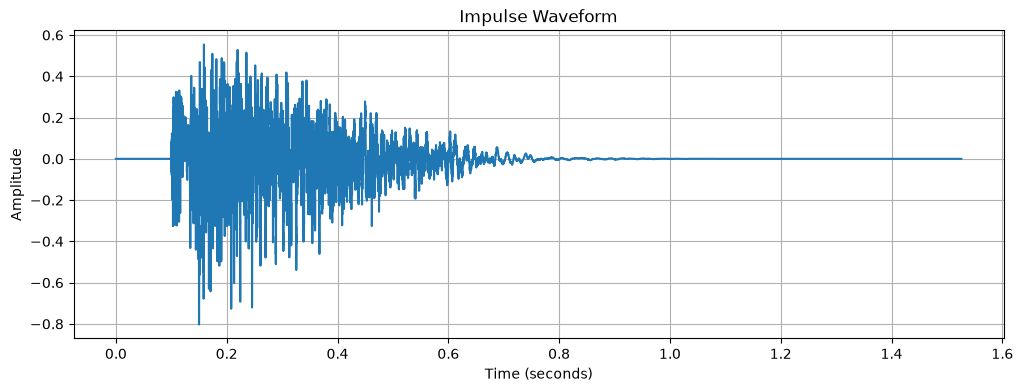

In [128]:
import matplotlib.pyplot as plt
import numpy as np

time = np.arange(len(impulse)) / sr

plt.figure(figsize=(12, 4))
plt.plot(time, impulse)
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.title("Impulse Waveform")
plt.grid()
plt.show()

In [129]:
clean, sr_clean = librosa.load(
    "../data/training/clean/speech1.wav",
    sr=16000,
    mono=True
)

clean_rms = np.sqrt(np.mean(clean ** 2))

print("Clean RMS:", clean_rms)

Clean RMS: 0.11327321
